In [4]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.messages import RemoveMessage

In [5]:
load_dotenv()

True

In [6]:
model = ChatGroq(model = "llama-3.3-70b-versatile")

In [7]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [8]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [9]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [10]:
graph = builder.compile(checkpointer=InMemorySaver())

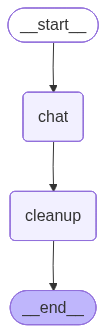

In [11]:
graph

In [12]:
config = {"configurable": {"thread_id": "t1"}}

In [13]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Nitish"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='42dcf296-93e6-42f5-b537-b21f5f8ad9ae'),
  AIMessage(content="LangChain is an open-source framework designed to simplify the development and deployment of large language models (LLMs) like LangGraph. It provides a modular and extensible architecture for building, training, and fine-tuning LLMs, as well as integrating them with various applications and services.\n\n**Key Features of LangChain**\n\n1. **Modular Architecture**: LangChain is built around a modular architecture, allowing developers to easily swap out or add new components, such as models, datasets, and training algorithms.\n2. **Pre-built Components**: LangChain provides a range of pre-built components, including models, datasets, and training scripts, to help developers get started with LLM development.\n3. **Extensive APIs**: LangChain offers extensive APIs for interacting with LLMs, making it easy to integrate them with

In [14]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
